# RFUAV Experiment 2 — Google Colab GPU Training with 6 class dataset

This notebook is a clean starter workflow for using Google Colab with the RFUAV dataset.

The goal of this notebook is to:

    Check whether Colab GPU is available.
    Mount Google Drive so model checkpoints are saved permanently.
    Install the required Python packages.
    Download a small RFUAV subset from Hugging Face.
    Arrange the dataset into a PyTorch ImageFolder format.
    Train a simple ResNet18 classifier on RF spectrogram images.
    Save the best model and generate a confusion matrix.


## 1. Enable GPU in Colab

Before running the notebook, go to:

Runtime → Change runtime type → Hardware accelerator → T4 GPU

Then run the cell below. If CUDA is available, PyTorch can use the GPU.

In [35]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected")


CUDA available: True
GPU: Tesla T4


## 2. Mount Google Drive

Colab temporary storage under `/content/` disappears when the runtime disconnects.

Google Drive storage under `/content/drive/MyDrive/` is permanent, so we save models, logs, and images there.

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Create project folders

This notebook uses two main locations:

- `/content/dataset` — fast temporary training data location.
- `/content/drive/MyDrive/RFUAV_Project` — permanent project folder for models and results.


In [37]:
import os

PROJECT_DIR = "/content/drive/MyDrive/RFUAV_Project"
DATASET_DIR = "/content/dataset"
RAW_DOWNLOAD_DIR = "/content/RFUAV_data"

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(RAW_DOWNLOAD_DIR, exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("Dataset folder:", DATASET_DIR)
print("Raw download folder:", RAW_DOWNLOAD_DIR)


Project folder: /content/drive/MyDrive/RFUAV_Project
Dataset folder: /content/dataset
Raw download folder: /content/RFUAV_data


## 4. Check PyTorch and CUDA versions

First, install all the nessessary library.

The `!` symbol means the command is executed as a Linux terminal command, not Python.

This is important because commands such as `pip install`, `mkdir`, and `huggingface-cli` are shell commands.

`
!pip install -U huggingface_hub
`

`
!pip install scikit-learn matplotlib pandas tqdm pillow pyyaml
`
This confirms that PyTorch is installed and whether it can see the GPU.

In [38]:
import torch
import torchvision

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA:", torch.cuda.is_available())

Torch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA: True


## 5. Download a small RFUAV subset

The `%%bash` line makes the whole cell run as a Linux terminal script. Without `%%bash` or `!`, Colab will treat `huggingface-cli` as Python and produce a `SyntaxError`.

In [44]:
%%bash

rm -rf /content/RFUAV_data_6class
mkdir -p /content/RFUAV_data_6class

hf download kitofrank/RFUAV \
  --repo-type dataset \
  --local-dir /content/RFUAV_data_6class \
  --include "ImageSet-AllDrones-MatlabPipeline/train/DJI MINI4 PRO/*" \
  --include "ImageSet-AllDrones-MatlabPipeline/valid/DJI MINI4 PRO/*" \
  --include "ImageSet-AllDrones-MatlabPipeline/train/FLYSKY FS I6X/*" \
  --include "ImageSet-AllDrones-MatlabPipeline/valid/FLYSKY FS I6X/*" \
  --include "ImageSet-AllDrones-MatlabPipeline/train/WFLY WFT09SII/*" \
  --include "ImageSet-AllDrones-MatlabPipeline/valid/WFLY WFT09SII/*" \
  --include "ImageSet-AllDrones-MatlabPipeline/train/YunZhuo-H12/*" \
  --include "ImageSet-AllDrones-MatlabPipeline/valid/YunZhuo-H12/*" \
  --include "ImageSet-AllDrones-MatlabPipeline/train/YunZhuo-H16/*" \
  --include "ImageSet-AllDrones-MatlabPipeline/valid/YunZhuo-H16/*" \
  --include "ImageSet-AllDrones-MatlabPipeline/train/YunZhuo-H30/*" \
  --include "ImageSet-AllDrones-MatlabPipeline/valid/YunZhuo-H30/*"

✓ Downloaded
  path: /content/RFUAV_data_6class


Number of files in the repo is unreliable. Using `list_repo_tree` to ensure all files are listed.
Fetching ... files: 2919it [02:36, 18.61it/s]


In [47]:
from pathlib import Path
import shutil

source_root = Path("/content/RFUAV_data_6class/ImageSet-AllDrones-MatlabPipeline")
dataset_root = Path("/content/dataset_6class")

if dataset_root.exists():
    shutil.rmtree(dataset_root)

class_candidates = {
    "DJI MINI4 PRO": ["DJI MINI4 PRO", "DJI-MINI4-PRO"],
    "FLYSKY FS I6X": ["FLYSKY FS I6X", "FLYSKY-FS-I6X"],
    "WFLY WFT09SII": ["WFLY WFT09SII", "WFLY-WFT09SII"],
    "YunZhuo-H12": ["YunZhuo-H12"],
    "YunZhuo-H16": ["YunZhuo-H16"],
    "YunZhuo-H30": ["YunZhuo-H30"],
}

for split in ["train", "valid"]:
    print("=" * 60)
    print(split.upper())

    for clean_class, possible_names in class_candidates.items():
        src = None

        for name in possible_names:
            candidate = source_root / split / name
            if candidate.exists():
                src = candidate
                break

        dst = dataset_root / split / clean_class
        dst.mkdir(parents=True, exist_ok=True)

        if src is None:
            print("Missing:", clean_class, "tried:", possible_names)
            continue

        files = [p for p in src.iterdir() if p.is_file()]

        for file in files:
            shutil.copy2(file, dst / file.name)

        print(f"Copied {len(files)} files: {split}/{src.name} -> {split}/{clean_class}")

print("Done.")

TRAIN
Copied 227 files: train/DJI MINI4 PRO -> train/DJI MINI4 PRO
Copied 115 files: train/FLYSKY FS I6X -> train/FLYSKY FS I6X
Copied 119 files: train/WFLY WFT09SII -> train/WFLY WFT09SII
Copied 93 files: train/YunZhuo-H12 -> train/YunZhuo-H12
Copied 184 files: train/YunZhuo-H16 -> train/YunZhuo-H16
Copied 129 files: train/YunZhuo-H30 -> train/YunZhuo-H30
VALID
Copied 546 files: valid/DJI MINI4 PRO -> valid/DJI MINI4 PRO
Copied 274 files: valid/FLYSKY FS I6X -> valid/FLYSKY FS I6X
Copied 283 files: valid/WFLY WFT09SII -> valid/WFLY WFT09SII
Copied 218 files: valid/YunZhuo-H12 -> valid/YunZhuo-H12
Copied 428 files: valid/YunZhuo-H16 -> valid/YunZhuo-H16
Copied 303 files: valid/YunZhuo-H30 -> valid/YunZhuo-H30
Done.


## 6. Check class counts

This is a quick sanity check.

You want each class folder to contain image files. If a class shows `0`, the folder path is probably wrong.


In [49]:
from pathlib import Path
from collections import Counter

dataset_root = Path("/content/dataset_6class")

for split in ["train", "valid"]:
    print("=" * 60)
    print(split.upper())

    split_dir = dataset_root / split
    for class_dir in sorted(split_dir.iterdir()):
        if class_dir.is_dir():
            count = len([p for p in class_dir.iterdir() if p.is_file()])
            print(f"{class_dir.name}: {count}")

TRAIN
DJI MINI4 PRO: 227
FLYSKY FS I6X: 115
WFLY WFT09SII: 119
YunZhuo-H12: 93
YunZhuo-H16: 184
YunZhuo-H30: 129
VALID
DJI MINI4 PRO: 546
FLYSKY FS I6X: 274
WFLY WFT09SII: 283
YunZhuo-H12: 218
YunZhuo-H16: 428
YunZhuo-H30: 303


## 7. Load the dataset with PyTorch

`ImageFolder` automatically assigns a numeric label to each class folder.

Example:

```text
YunZhuo-H12 → 0
YunZhuo-H16 → 1
YunZhuo-H30 → 2
```

The exact mapping is printed below.


In [55]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_dir = "/content/dataset_6class/train"
valid_dir = "/content/dataset_6class/valid"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
valid_dataset = datasets.ImageFolder(valid_dir, transform=transform)

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)
print("Train images:", len(train_dataset))
print("Valid images:", len(valid_dataset))

Classes: ['DJI MINI4 PRO', 'FLYSKY FS I6X', 'WFLY WFT09SII', 'YunZhuo-H12', 'YunZhuo-H16', 'YunZhuo-H30']
Class mapping: {'DJI MINI4 PRO': 0, 'FLYSKY FS I6X': 1, 'WFLY WFT09SII': 2, 'YunZhuo-H12': 3, 'YunZhuo-H16': 4, 'YunZhuo-H30': 5}
Train images: 867
Valid images: 2052


## 8. Train a ResNet18 classifier

This is a simple supervised baseline.

The model learns to classify RF spectrogram images into the three selected UAV/controller classes.

Main settings:

- Model: `ResNet18`
- Input size: `224 × 224`
- Batch size: `32`
- Epochs: `5`
- Optimizer: `Adam`
- Loss: `CrossEntropyLoss`

Outputs saved to Google Drive:

- `best.pt` — best validation model
- `last.pt` — final model after training
- `history.csv` — training/validation accuracy log
- `classes.json` — class label mapping


In [56]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

# -----------------------------
# Settings
# -----------------------------

train_dir = "/content/dataset_6class/train"
valid_dir = "/content/dataset_6class/valid"

save_dir = "/content/drive/MyDrive/RFUAV_Project/models/resnet18_6class"
os.makedirs(save_dir, exist_ok=True)

batch_size = 32
epochs = 5
lr = 0.001

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# Data transforms
# -----------------------------

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
valid_dataset = datasets.ImageFolder(valid_dir, transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)
print("Train images:", len(train_dataset))
print("Valid images:", len(valid_dataset))

# -----------------------------
# Model
# -----------------------------

num_classes = len(train_dataset.classes)

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# -----------------------------
# Training loop
# -----------------------------

history = []
best_acc = 0.0

for epoch in range(epochs):
    print("=" * 60)
    print(f"Epoch {epoch + 1}/{epochs}")

    # Train
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss / train_total
    train_acc = train_correct / train_total

    # Validate
    model.eval()
    valid_loss = 0.0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():
        for images, labels in tqdm(valid_loader, desc="Validation"):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            valid_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            valid_correct += (preds == labels).sum().item()
            valid_total += labels.size(0)

    valid_loss = valid_loss / valid_total
    valid_acc = valid_correct / valid_total

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f}")
    print(f"Valid Acc : {valid_acc:.4f}")

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "valid_loss": valid_loss,
        "valid_acc": valid_acc,
    })

    # Save best model
    if valid_acc > best_acc:
        best_acc = valid_acc
        torch.save(model.state_dict(), os.path.join(save_dir, "best.pt"))
        print("Saved new best model.")

# Save last model
torch.save(model.state_dict(), os.path.join(save_dir, "last.pt"))

# Save history
history_df = pd.DataFrame(history)
history_path = os.path.join(save_dir, "history.csv")
history_df.to_csv(history_path, index=False)

print("=" * 60)
print("Training finished.")
print("Best validation accuracy:", best_acc)
print("Saved history to:", history_path)
print("Saved models to:", save_dir)

Using device: cuda
Classes: ['DJI MINI4 PRO', 'FLYSKY FS I6X', 'WFLY WFT09SII', 'YunZhuo-H12', 'YunZhuo-H16', 'YunZhuo-H30']
Class mapping: {'DJI MINI4 PRO': 0, 'FLYSKY FS I6X': 1, 'WFLY WFT09SII': 2, 'YunZhuo-H12': 3, 'YunZhuo-H16': 4, 'YunZhuo-H30': 5}
Train images: 867
Valid images: 2052
Epoch 1/10


Validation: 100%|██████████| 65/65 [01:24<00:00,  1.29s/it]


Train Loss: 0.5826
Train Acc : 0.7935
Valid Loss: 4.6293
Valid Acc : 0.1477
Saved new best model.
Epoch 2/10


Validation: 100%|██████████| 65/65 [01:12<00:00,  1.11s/it]


Train Loss: 0.0911
Train Acc : 0.9792
Valid Loss: 0.6595
Valid Acc : 0.8319
Saved new best model.
Epoch 3/10


...

Train Loss: 0.0592
Train Acc : 0.9804
Valid Loss: 0.0585
Valid Acc : 0.9937
Epoch 9/10


Validation: 100%|██████████| 65/65 [01:13<00:00,  1.13s/it]


Train Loss: 0.0455
Train Acc : 0.9885
Valid Loss: 0.0329
Valid Acc : 0.9951
Saved new best model.
Epoch 10/10


Validation: 100%|██████████| 65/65 [01:14<00:00,  1.15s/it]


Train Loss: 0.0453
Train Acc : 0.9896
Valid Loss: 0.0771
Valid Acc : 0.9708
Training finished.
Best validation accuracy: 0.9951267056530214
Saved history to: /content/drive/MyDrive/RFUAV_Project/models/resnet18_6class/history.csv
Saved models to: /content/drive/MyDrive/RFUAV_Project/models/resnet18_6class


## 9. Preview a few spectrogram images

This helps confirm that the dataset is being loaded correctly.

The images are RF spectrogram-style images, so they may look like heatmaps or frequency-time patterns.

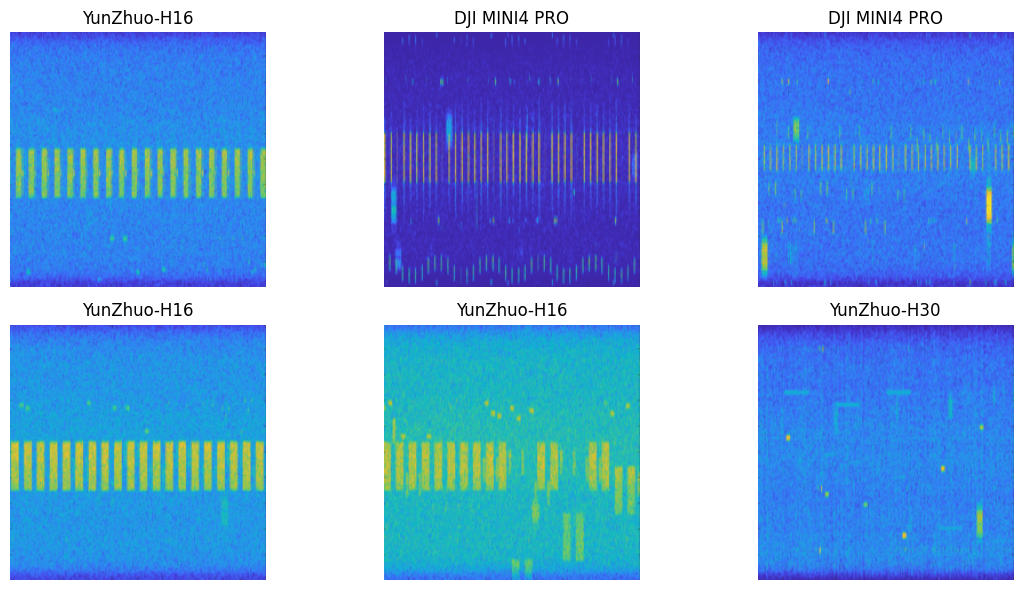

In [57]:
import matplotlib.pyplot as plt
import random

num_images = min(6, len(train_dataset))
indices = random.sample(range(len(train_dataset)), num_images)

plt.figure(figsize=(12, 6))
for i, idx in enumerate(indices):
    image, label = train_dataset[idx]
    image_np = image.permute(1, 2, 0).numpy()

    plt.subplot(2, 3, i + 1)
    plt.imshow(image_np)
    plt.title(train_dataset.classes[label])
    plt.axis("off")

plt.tight_layout()
plt.show()


## 10. Plot training curves

This shows whether the model is learning or overfitting.

Useful signs:

- Training accuracy increases → the model is learning the training set.
- Validation accuracy increases → the model generalizes better.
- Training accuracy high but validation accuracy low → possible overfitting.
- Very high validation accuracy too quickly → check for possible data leakage or duplicate files.


,epoch,train_loss,train_acc,valid_loss,valid_acc
0,1,0.582620,0.793541,4.629260,0.147661
1,2,0.091097,0.979239,0.659463,0.831871
2,3,0.090666,0.976932,0.140602,0.960039
3,4,0.056690,0.980392,4.261757,0.703704
4,5,0.023804,0.995386,0.021539,0.993665
5,6,0.013169,0.997693,0.295171,0.895712
6,7,0.107738,0.966551,1.234315,0.690546
7,8,0.059230,0.980392,0.058478,0.993665
8,9,0.045474,0.988466,0.032876,0.995127
9,10,0.045261,0.989619,0.077144,0.970760


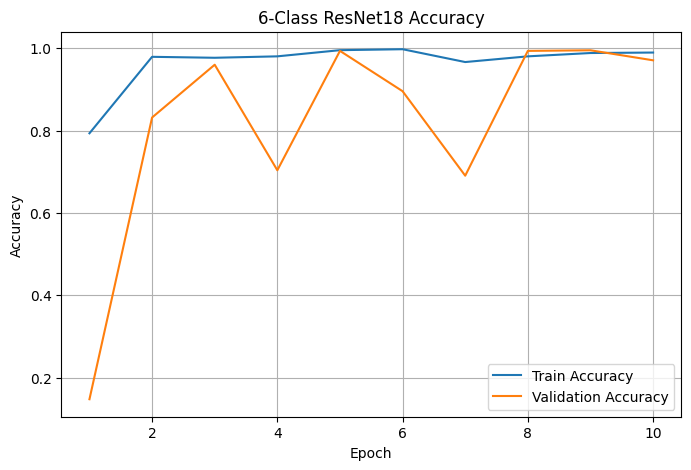

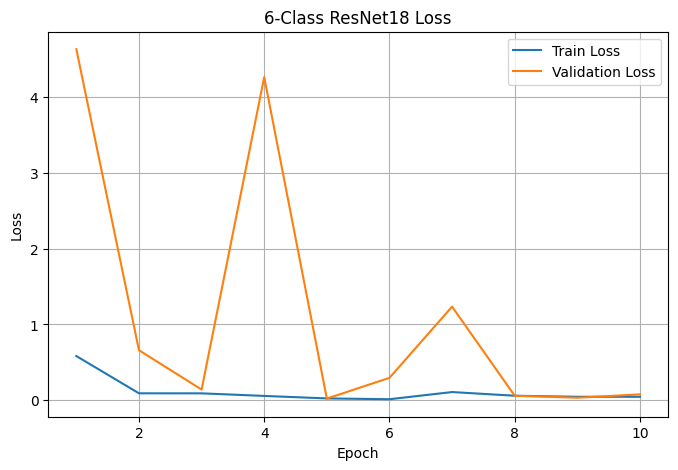

In [58]:
import os
import pandas as pd
import matplotlib.pyplot as plt

save_dir = "/content/drive/MyDrive/RFUAV_Project/models/resnet18_6class"
history_path = os.path.join(save_dir, "history.csv")

history_df = pd.read_csv(history_path)
display(history_df)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["valid_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("6-Class ResNet18 Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["valid_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("6-Class ResNet18 Loss")
plt.legend()
plt.grid(True)
plt.show()

## 11. Confusion matrix and classification report

The confusion matrix shows which classes are being confused with each other.

For example, if many `YunZhuo-H12` samples are predicted as `YunZhuo-H16`, then the model may be learning features that are not strong enough to separate those two classes.


               precision    recall  f1-score   support

DJI MINI4 PRO       0.99      0.90      0.95       546
FLYSKY FS I6X       1.00      1.00      1.00       274
WFLY WFT09SII       1.00      1.00      1.00       283
  YunZhuo-H12       1.00      0.98      0.99       218
  YunZhuo-H16       1.00      1.00      1.00       428
  YunZhuo-H30       0.84      1.00      0.91       303

     accuracy                           0.97      2052
    macro avg       0.97      0.98      0.97      2052
 weighted avg       0.97      0.97      0.97      2052



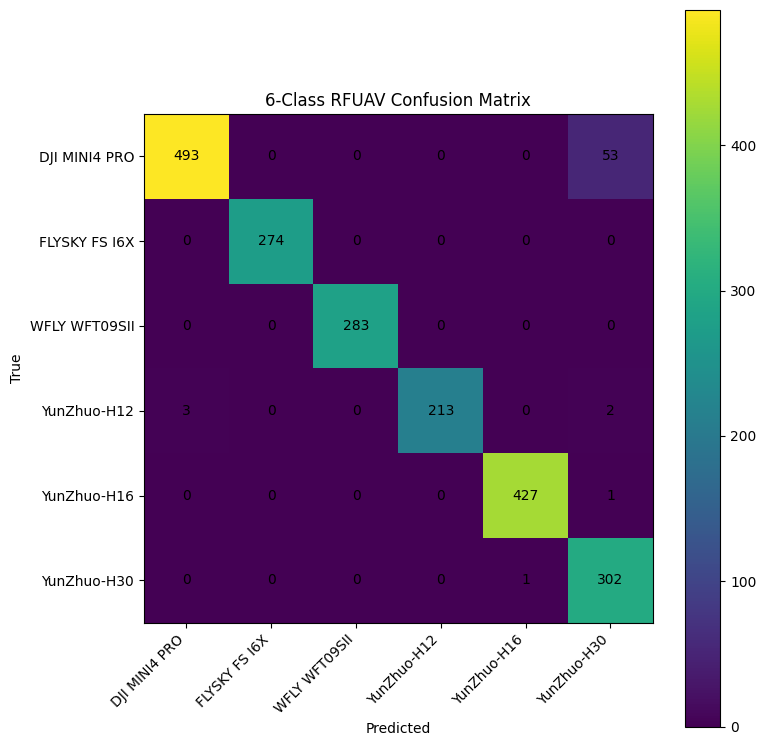

Saved confusion matrix to: /content/drive/MyDrive/RFUAV_Project/models/resnet18_6class/confusion_matrix_6class.png


In [59]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(
    all_labels,
    all_preds,
    target_names=valid_dataset.classes
))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 8))
plt.imshow(cm)
plt.title("6-Class RFUAV Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(np.arange(len(valid_dataset.classes)), valid_dataset.classes, rotation=45, ha="right")
plt.yticks(np.arange(len(valid_dataset.classes)), valid_dataset.classes)
plt.colorbar()

for i in range(len(valid_dataset.classes)):
    for j in range(len(valid_dataset.classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()

cm_path = os.path.join(save_dir, "confusion_matrix_6class.png")
plt.savefig(cm_path, dpi=200)
plt.show()

print("Saved confusion matrix to:", cm_path)

## 12. Optional: test one image manually

Change `image_path` to any image from the validation set.

This is useful after training because it shows the predicted class for a single spectrogram.


Testing image: /content/dataset/valid/YunZhuo-H16/yunzhuo-H16244.jpg
Predicted class: YunZhuo-H16
Confidence: 0.999998927116394


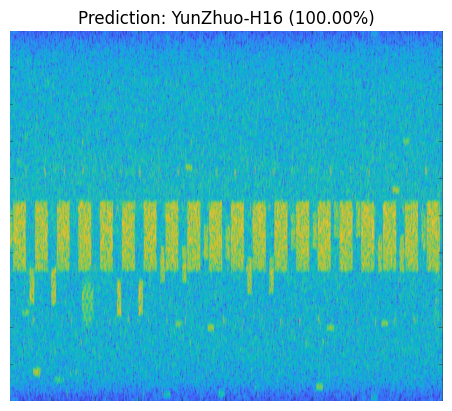

In [60]:
from PIL import Image
import torch
import os

# Pick one validation image automatically
image_path = None
for root, dirs, files in os.walk("/content/dataset/valid"):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            image_path = os.path.join(root, file)
            break
    if image_path is not None:
        break

print("Testing image:", image_path)

image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.softmax(output, dim=1)
    confidence, predicted_idx = torch.max(probabilities, 1)

predicted_class = valid_dataset.classes[predicted_idx.item()]
print("Predicted class:", predicted_class)
print("Confidence:", confidence.item())

plt.imshow(image)
plt.title(f"Prediction: {predicted_class} ({confidence.item():.2%})")
plt.axis("off")
plt.show()


In [61]:
from pathlib import Path
from PIL import Image
import imagehash
from collections import defaultdict

train_dir = Path("/content/dataset_6class/train")
valid_dir = Path("/content/dataset_6class/valid")

def compute_hashes(root):
    hashes = defaultdict(list)

    for path in root.rglob("*"):
        if path.is_file() and path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            try:
                img = Image.open(path).convert("RGB")
                h = imagehash.phash(img)
                cls = path.parent.name
                hashes[cls].append((h, path))
            except Exception as e:
                print("Error reading:", path, e)

    return hashes

train_hashes = compute_hashes(train_dir)
valid_hashes = compute_hashes(valid_dir)

total_valid = 0
total_similar = 0

for cls in sorted(train_hashes.keys()):
    print("=" * 60)
    print("Class:", cls)

    close_matches = []

    for vh, vpath in valid_hashes[cls]:
        for th, tpath in train_hashes[cls]:
            distance = vh - th

            if distance <= 5:
                close_matches.append((distance, vpath.name, tpath.name))
                break

    total_valid += len(valid_hashes[cls])
    total_similar += len(close_matches)

    print("Valid images:", len(valid_hashes[cls]))
    print("Very similar valid images found in train:", len(close_matches))

    if close_matches:
        print("Examples:")
        for item in close_matches[:10]:
            print(item)

print("=" * 60)
print("Total valid images:", total_valid)
print("Total near-duplicates:", total_similar)
print("Near-duplicate percentage:", total_similar / total_valid * 100, "%")

Class: DJI MINI4 PRO
Valid images: 546
Very similar valid images found in train: 0
Class: FLYSKY FS I6X
Valid images: 274
Very similar valid images found in train: 11
Examples:
(4, 'FLYSKY FS I6X196.jpg', 'FLYSKY FS I6X131.jpg')
(4, 'FLYSKY FS I6X168.jpg', 'FLYSKY FS I6X27.jpg')
(4, 'FLYSKY FS I6X183.jpg', 'FLYSKY FS I6X28.jpg')
(4, 'FLYSKY FS I6X207.jpg', 'FLYSKY FS I6X123.jpg')
(4, 'FLYSKY FS I6X77.jpg', 'FLYSKY FS I6X134.jpg')
(4, 'FLYSKY FS I6X371.jpg', 'FLYSKY FS I6X284.jpg')
(4, 'FLYSKY FS I6X172.jpg', 'FLYSKY FS I6X122.jpg')
(4, 'FLYSKY FS I6X85.jpg', 'FLYSKY FS I6X279.jpg')
(4, 'FLYSKY FS I6X234.jpg', 'FLYSKY FS I6X148.jpg')
(4, 'FLYSKY FS I6X382.jpg', 'FLYSKY FS I6X272.jpg')
Class: WFLY WFT09SII
Valid images: 283
Very similar valid images found in train: 0
Class: YunZhuo-H12
Valid images: 218
Very similar valid images found in train: 0
Class: YunZhuo-H16
Valid images: 428
Very similar valid images found in train: 7
Examples:
(4, 'yunzhuo-H16404.jpg', 'yunzhuo-H1665.jpg')
(4, '